# 🚀 Finocyl Inverse Model — Version 2 (Fixed)
## التحليل الكامل للمشاكل والحلول

### ❌ المشاكل في الموديل القديم:

1. **فقدان المعلومات الأكثر أهمية**: الـ normalization بـ `thr /= max(thr)` يمسح المعلومات المطلقة تمامًا. الموديل لا يعرف فرق بين `Max Thrust = 5000N` أو `120000N` — وهي المعلومة الرئيسية!

2. **3330 sample فقط** مع موديل ضخم → Overfitting مضمون. نسبة الـ parameters للـ samples كبيرة جدًا.

3. **فقدان Burn Time**: الوقت يُطمس بالـ time normalization. `Burn Time` هو أقوى predictor لـ `Length`!

4. **Throat/Exit Diameter R² = 0.05**: هذان البُعدان يعتمدان بشكل أساسي على peak pressure وليس على الـ shape — الحل: إضافة scalar features.

5. **Batch Size 32 صغير** مع 3330 sample → gradients غير مستقرة.

6. **Loss = Huber بدون weighting**: كل الأبعاد بنفس الوزن رغم اختلاف scales جذريًا (Length: 20-130 vs Fin_Width: 0.2-2.2).

### ✅ الحلول:
- إضافة **6 scalar features** (Max Thrust, Avg Thrust, Burn Time, Peak Pressure, Total Impulse, Rise Time)
- **Hybrid input**: شكل الـ curve + القيم المطلقة
- **Data Augmentation** لتضخيم البيانات
- **Per-output loss weighting** بناءً على variance
- **أرشيتكتشر أصغر** لتجنب Overfitting
- **K-Fold cross validation** للتحقق الحقيقي


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INV_NUM_POINTS = 128
INPUT_COLS = ['Diameter', 'Length', 'Core_Diameter', 'Number_Of_Fins',
              'Fin_Length', 'Fin_Width', 'Throat_Diameter', 'Exit_Diameter']


2026-05-19 15:05:05.196359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779203105.427876      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779203105.490516      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779203106.017700      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779203106.017744      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779203106.017746      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: True


In [2]:
FILE_PATH = '/kaggle/input/datasets/mohamedeidshehata6/finocyl-new-data/Finocyl_new_data.csv'

df = pd.read_csv(FILE_PATH, on_bad_lines='skip', skip_blank_lines=True)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Unique models:", df['ID'].nunique())


Shape: (3327665, 18)
Unique models: 3900


In [3]:
# ============================================================
# FIXED DATA PREPARATION
# الإصلاح الجوهري: إضافة Scalar Features تحمل المعلومات المطلقة
# ============================================================

def extract_scalar_features(t, thrust, press):
    """
    استخراج 6 features مطلقة من كل curve.
    هذه الـ features تحمل المعلومات التي تُفقدها الـ normalization.
    """
    max_thrust    = np.max(thrust)
    max_press     = np.max(press)
    burn_time     = t[-1] - t[0]                    # المدة الفعلية بالثواني
    avg_thrust    = np.trapz(thrust, t) / (burn_time + 1e-8)
    total_impulse = np.trapz(thrust, t)
    
    # Rise time: الوقت للوصول لـ 90% من max thrust
    idx_90 = np.argmax(thrust >= 0.9 * max_thrust)
    rise_time = t[idx_90] / (burn_time + 1e-8) if max_thrust > 0 else 0.5
    
    return np.array([
        np.log1p(max_thrust),      # log scale لتقليل skewness
        np.log1p(max_press),
        np.log1p(burn_time),
        np.log1p(avg_thrust),
        np.log1p(total_impulse),
        rise_time
    ], dtype=np.float32)


def prepare_inverse_data_v2(df, num_points=INV_NUM_POINTS):
    ids = df['ID'].dropna().unique()
    X_thrust, X_pressure, X_scalar, Y_geom = [], [], [], []
    skipped = 0

    for uid in ids:
        try:
            case = df[df['ID'] == uid].sort_values('Time (s)')
            geom = case[INPUT_COLS].iloc[0].values.astype(float)

            if np.any(np.isnan(geom)) or np.any(geom <= 0):
                skipped += 1; continue

            t      = case['Time (s)'].values.astype(float)
            thrust = case['Thrust (N)'].fillna(0).values.astype(float)
            press  = case['Pressure (MPa)'].fillna(0).values.astype(float)

            if len(t) < 10 or t[-1] <= 0 or np.max(thrust) <= 0:
                skipped += 1; continue

            # ── Scalar features (BEFORE normalization) ──────────────
            scalars = extract_scalar_features(t, thrust, press)

            # ── Shape curves (normalized) ───────────────────────────
            t_norm = (t - t[0]) / (t[-1] - t[0])
            t_new  = np.linspace(0, 1, num_points)

            thr_r = np.clip(interp1d(t_norm, thrust, kind='linear',
                                     fill_value='extrapolate')(t_new), 0, None)
            prs_r = np.clip(interp1d(t_norm, press, kind='linear',
                                     fill_value='extrapolate')(t_new), 0, None)

            # Normalize shape only (0-1)
            thr_r /= (np.max(thr_r) + 1e-8)
            prs_r /= (np.max(prs_r) + 1e-8)

            thr_r = np.clip(savgol_filter(thr_r, 15, 3), 0, None)
            prs_r = np.clip(savgol_filter(prs_r, 15, 3), 0, None)

            X_thrust.append(thr_r)
            X_pressure.append(prs_r)
            X_scalar.append(scalars)
            Y_geom.append(geom)

        except Exception:
            skipped += 1; continue

    print(f"✅ {len(X_thrust)} cases | Skipped: {skipped}")
    return (np.array(X_thrust,   dtype=np.float32),
            np.array(X_pressure, dtype=np.float32),
            np.array(X_scalar,   dtype=np.float32),
            np.array(Y_geom,     dtype=np.float32))


Xt_inv, Xp_inv, Xs_inv, Y_geom = prepare_inverse_data_v2(df)
print(f"Thrust  curves : {Xt_inv.shape}")
print(f"Pressure curves: {Xp_inv.shape}")
print(f"Scalar features: {Xs_inv.shape}")
print(f"Geometry       : {Y_geom.shape}")


✅ 3832 cases | Skipped: 68
Thrust  curves : (3832, 128)
Pressure curves: (3832, 128)
Scalar features: (3832, 6)
Geometry       : (3832, 8)


In [4]:
# ============================================================
# DATA AUGMENTATION
# مضاعفة البيانات من 3330 → ~13000 sample للحد من Overfitting
# ============================================================

def augment_data(Xt, Xp, Xs, Yg, factor=3, noise_std=0.008):
    """
    Augmentation محافظ:
    - Gaussian noise خفيف على الـ curves
    - Time warping طفيف (stretch/compress)
    - لا نغير الـ scalar features لأنها مطلقة
    """
    N = len(Xt)
    all_Xt = [Xt]
    all_Xp = [Xp]
    all_Xs = [Xs]
    all_Yg = [Yg]
    
    for _ in range(factor):
        noise_t = np.random.normal(0, noise_std, Xt.shape).astype(np.float32)
        noise_p = np.random.normal(0, noise_std, Xp.shape).astype(np.float32)
        
        # Time warp: stretch بشكل random لكل sample
        warp_factor = np.random.uniform(0.92, 1.08, (N, 1)).astype(np.float32)
        
        xt_aug = np.clip(Xt + noise_t, 0, 1)
        xp_aug = np.clip(Xp + noise_p, 0, 1)
        
        # Scalar noise أصغر بكثير (2%)
        xs_aug = Xs + np.random.normal(0, 0.02, Xs.shape).astype(np.float32)
        
        all_Xt.append(xt_aug)
        all_Xp.append(xp_aug)
        all_Xs.append(xs_aug)
        all_Yg.append(Yg)  # geometry لا تتغير
    
    return (np.concatenate(all_Xt), np.concatenate(all_Xp),
            np.concatenate(all_Xs), np.concatenate(all_Yg))


# Split BEFORE augmentation (مهم جدًا! لا نضيف augmented data في validation/test)
(Xt_tmp, Xt_te, Xp_tmp, Xp_te, Xs_tmp, Xs_te, Yg_tmp, Yg_te) = train_test_split(
    Xt_inv, Xp_inv, Xs_inv, Y_geom, test_size=0.10, random_state=SEED)

(Xt_tr, Xt_val, Xp_tr, Xp_val, Xs_tr, Xs_val, Yg_tr, Yg_val) = train_test_split(
    Xt_tmp, Xp_tmp, Xs_tmp, Yg_tmp, test_size=0.15, random_state=SEED)

print(f"Before augmentation - Train: {len(Xt_tr)}")

# Augment training data فقط
Xt_tr_aug, Xp_tr_aug, Xs_tr_aug, Yg_tr_aug = augment_data(
    Xt_tr, Xp_tr, Xs_tr, Yg_tr, factor=3)

print(f"After  augmentation - Train: {len(Xt_tr_aug)}")
print(f"Val: {len(Xt_val)} | Test: {len(Xt_te)}")

# Scaler على geometry
inv_scaler_Y = RobustScaler()
Yg_tr_s  = inv_scaler_Y.fit_transform(Yg_tr_aug)
Yg_val_s = inv_scaler_Y.transform(Yg_val)
Yg_te_s  = inv_scaler_Y.transform(Yg_te)

# Scaler على scalar features
inv_scaler_S = StandardScaler()
Xs_tr_s  = inv_scaler_S.fit_transform(Xs_tr_aug)
Xs_val_s = inv_scaler_S.transform(Xs_val)
Xs_te_s  = inv_scaler_S.transform(Xs_te)

joblib.dump(inv_scaler_Y, 'finocyl_inv_scaler_Y_v2.pkl')
joblib.dump(inv_scaler_S, 'finocyl_inv_scaler_S_v2.pkl')
print("✅ Scalers saved!")


Before augmentation - Train: 2930
After  augmentation - Train: 11720
Val: 518 | Test: 384
✅ Scalers saved!


In [5]:
# ============================================================
# IMPROVED MODEL ARCHITECTURE
# الإصلاح: Hybrid CNN + Scalar Branch + Per-Output Weighting
# ============================================================

L2 = 1e-4  # L2 regularization لمنع Overfitting

def conv_block_v2(x, filters, kernel=5, l2=L2):
    """Residual Conv block مع L2 regularization"""
    shortcut = layers.Conv1D(filters, 1, padding='same',
                             kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Conv1D(filters, kernel, padding='same', activation='elu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(filters, kernel, padding='same', activation='elu',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.LayerNormalization()(x)
    return layers.Add()([x, shortcut])


def residual_block_v2(x, units, dropout=0.2, l2=L2):
    """Residual Dense block مع dropout أعلى قليلًا"""
    shortcut = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dense(units, activation='elu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(units, activation='elu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.LayerNormalization()(x)
    return layers.Add()([x, shortcut])


def build_curve_encoder_v2(name, num_points=INV_NUM_POINTS):
    """
    Encoder أصغر وأكثر تنظيمًا:
    - 3 conv blocks بدلًا من 3 مع channels أقل
    - L2 regularization
    """
    inp = layers.Input(shape=(num_points, 1), name=f'{name}_input')
    x = conv_block_v2(inp, 32, kernel=9)   # أول layer: kernel كبير لـ long-range patterns
    x = layers.MaxPooling1D(2)(x)          # 128 → 64
    x = conv_block_v2(x,  64, kernel=5)
    x = layers.MaxPooling1D(2)(x)          # 64 → 32
    x = conv_block_v2(x, 128, kernel=3)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='elu',
                     kernel_regularizer=regularizers.l2(L2))(x)
    return Model(inputs=inp, outputs=x, name=f'{name}_Encoder_v2')


def build_inverse_model_v2(num_points=INV_NUM_POINTS, n_scalars=6):
    """
    Hybrid Architecture:
    - Curve Branch: CNN على شكل الـ curves (normalized)
    - Scalar Branch: Dense على القيم المطلقة
    - Fusion: Concatenate + Residual Decoder
    
    هذا يحل مشكلة: Throat/Exit Diameter يحتاجان Max Pressure
    وLength يحتاج Burn Time — وهذه معلومات تُفقد بالـ normalization
    """
    # ── Inputs ──────────────────────────────────────────────
    inp_thrust  = layers.Input(shape=(num_points,), name='Thrust_Curve')
    inp_press   = layers.Input(shape=(num_points,), name='Pressure_Curve')
    inp_scalars = layers.Input(shape=(n_scalars,),  name='Scalar_Features')

    # ── Curve Branch ────────────────────────────────────────
    t_seq = layers.Reshape((num_points, 1))(inp_thrust)
    p_seq = layers.Reshape((num_points, 1))(inp_press)

    thrust_enc   = build_curve_encoder_v2('Thrust',   num_points)
    pressure_enc = build_curve_encoder_v2('Pressure', num_points)

    t_feat = thrust_enc(t_seq)     # (batch, 64)
    p_feat = pressure_enc(p_seq)   # (batch, 64)

    # Cross-attention gate (نفس فكرة الموديل القديم لكن على 64 dims)
    t_w    = layers.Dense(64, activation='sigmoid')(p_feat)
    p_w    = layers.Dense(64, activation='sigmoid')(t_feat)
    t_gate = layers.Multiply()([t_feat, t_w])
    p_gate = layers.Multiply()([p_feat, p_w])
    curve_feat = layers.Concatenate()([t_gate, p_gate])  # (batch, 128)

    # ── Scalar Branch ────────────────────────────────────────
    # الـ scalar branch: يحمل burn time, max thrust, etc.
    s = layers.Dense(32, activation='elu',
                     kernel_regularizer=regularizers.l2(L2))(inp_scalars)
    s = layers.LayerNormalization()(s)
    s = layers.Dense(32, activation='elu',
                     kernel_regularizer=regularizers.l2(L2))(s)
    scalar_feat = layers.LayerNormalization()(s)           # (batch, 32)

    # ── Fusion ───────────────────────────────────────────────
    x = layers.Concatenate()([curve_feat, scalar_feat])   # (batch, 160)
    x = residual_block_v2(x, 128, dropout=0.20)
    x = residual_block_v2(x,  64, dropout=0.15)
    x = residual_block_v2(x,  32, dropout=0.10)

    out = layers.Dense(8, activation='linear',
                       name='Geometry_Output')(x)

    return Model(inputs=[inp_thrust, inp_press, inp_scalars],
                 outputs=out, name='Finocyl_Inverse_Model_v2')


inv_model_v2 = build_inverse_model_v2()
inv_model_v2.summary()
print(f"\nTotal params: {inv_model_v2.count_params():,}")


I0000 00:00:1779203158.699794      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779203158.705716      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Finocyl_Inverse_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Thrust_Curve        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Curve      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 1)    │          0 │ Thrust_Curve[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 1)    │          0 │ Pressure_Curve[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalar_Features     │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Thrust_Encoder_v2   │ (None, 64)        │    134,048 │ reshape[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Encoder_v2 │ (None, 64)        │    134,048 │ reshape_1[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        224 │ Scalar_Features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ Pressure_Encoder… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ Thrust_Encoder_v… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense_4[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64)        │          0 │ Thrust_Encoder_v… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 64)        │          0 │ Pressure_Encoder… │
│ (Multiply)          │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ multiply[0][0],   │
│ (Concatenate)       │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense_5[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     20,608 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ dense_7[0][0]     │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 362,600 (1.38 MB)

 Trainable params: 362,600 (1.38 MB)

 Non-trainable params: 0 (0.00 B)


Total params: 362,600


In [6]:
# ============================================================
# PER-OUTPUT WEIGHTED LOSS
# الإصلاح: كل بُعد له وزن عكسي لـ variance ليكون التعلم متوازن
# ============================================================

# احسب variance كل output في training data
output_stds = np.std(Yg_tr_aug, axis=0)
print("Output stds:", dict(zip(INPUT_COLS, output_stds.round(3))))

# الوزن = 1/std (بعد normalization)
raw_weights = 1.0 / (output_stds + 1e-8)
output_weights = (raw_weights / raw_weights.mean()).astype(np.float32)
print("Output weights:", dict(zip(INPUT_COLS, output_weights.round(3))))


def weighted_huber_loss(y_true, y_pred, weights=output_weights, delta=1.0):
    """Huber loss مع per-output weighting"""
    weights_tensor = tf.constant(weights, dtype=tf.float32)
    error = y_true - y_pred
    abs_error = tf.abs(error)
    quadratic = tf.minimum(abs_error, delta)
    linear = abs_error - quadratic
    huber = 0.5 * quadratic**2 + delta * linear
    weighted = huber * weights_tensor
    return tf.reduce_mean(weighted)


inv_model_v2.compile(
    optimizer=Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=weighted_huber_loss,
    metrics=['mae']
)

callbacks_inv = [
    EarlyStopping(monitor='val_loss', patience=60,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4,
                      patience=20, min_lr=5e-7, verbose=1),
    ModelCheckpoint('finocyl_inv_best_v2.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

print("\n🔄 Training Improved Inverse Model v2...")
print("Expected improvement:")
print("  - Throat/Exit Diameter: R² > 0.7 (كان 0.05)")
print("  - Length: R² > 0.8 (كان 0.57)")
print("  - Core_Diameter: R² > 0.85 (كان 0.79)")

hist_inv = inv_model_v2.fit(
    x=[Xt_tr_aug, Xp_tr_aug, Xs_tr_s],
    y=Yg_tr_s,
    validation_data=([Xt_val, Xp_val, Xs_val_s], Yg_val_s),
    epochs=500,
    batch_size=64,    # batch أكبر = gradients أكثر استقرارًا مع البيانات الـ augmented
    callbacks=callbacks_inv,
    verbose=1
)

inv_model_v2.save('Finocyl_Inverse_Model_v2.keras')
print("\n✅ Saved: Finocyl_Inverse_Model_v2.keras")


Output stds: {'Diameter': np.float32(4.182), 'Length': np.float32(34.396), 'Core_Diameter': np.float32(1.33), 'Number_Of_Fins': np.float32(2.685), 'Fin_Length': np.float32(1.105), 'Fin_Width': np.float32(0.462), 'Throat_Diameter': np.float32(0.265), 'Exit_Diameter': np.float32(0.397)}
Output weights: {'Diameter': np.float32(0.178), 'Length': np.float32(0.022), 'Core_Diameter': np.float32(0.559), 'Number_Of_Fins': np.float32(0.277), 'Fin_Length': np.float32(0.673), 'Fin_Width': np.float32(1.611), 'Throat_Diameter': np.float32(2.808), 'Exit_Diameter': np.float32(1.872)}

🔄 Training Improved Inverse Model v2...
Expected improvement:
  - Throat/Exit Diameter: R² > 0.7 (كان 0.05)
  - Length: R² > 0.8 (كان 0.57)
  - Core_Diameter: R² > 0.85 (كان 0.79)
Epoch 1/500


I0000 00:00:1779203177.581955     143 service.cc:152] XLA service 0x7a4ab8003970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779203177.581993     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779203177.581997     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779203182.018353     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  9/184 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.3262 - mae: 2.4656  

I0000 00:00:1779203196.501338     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


184/184 ━━━━━━━━━━━━━━━━━━━━ 60s 132ms/step - loss: 0.8584 - mae: 1.1039 - val_loss: 0.2992 - val_mae: 0.3752 - learning_rate: 3.0000e-04
Epoch 2/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.3477 - mae: 0.4908 - val_loss: 0.2747 - val_mae: 0.3164 - learning_rate: 3.0000e-04
Epoch 3/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3084 - mae: 0.4079 - val_loss: 0.2622 - val_mae: 0.2824 - learning_rate: 3.0000e-04
Epoch 4/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2863 - mae: 0.3586 - val_loss: 0.2522 - val_mae: 0.2630 - learning_rate: 3.0000e-04
Epoch 5/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2733 - mae: 0.3316 - val_loss: 0.2458 - val_mae: 0.2522 - learning_rate: 3.0000e-04
Epoch 6/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2607 - mae: 0.3107 - val_loss: 0.2447 - val_mae: 0.2560 - learning_rate: 3.0000e-04
Epoch 7/500
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2488 - mae: 0.2943 - val_loss: 0.2302 - val_mae: 0.2406 - 

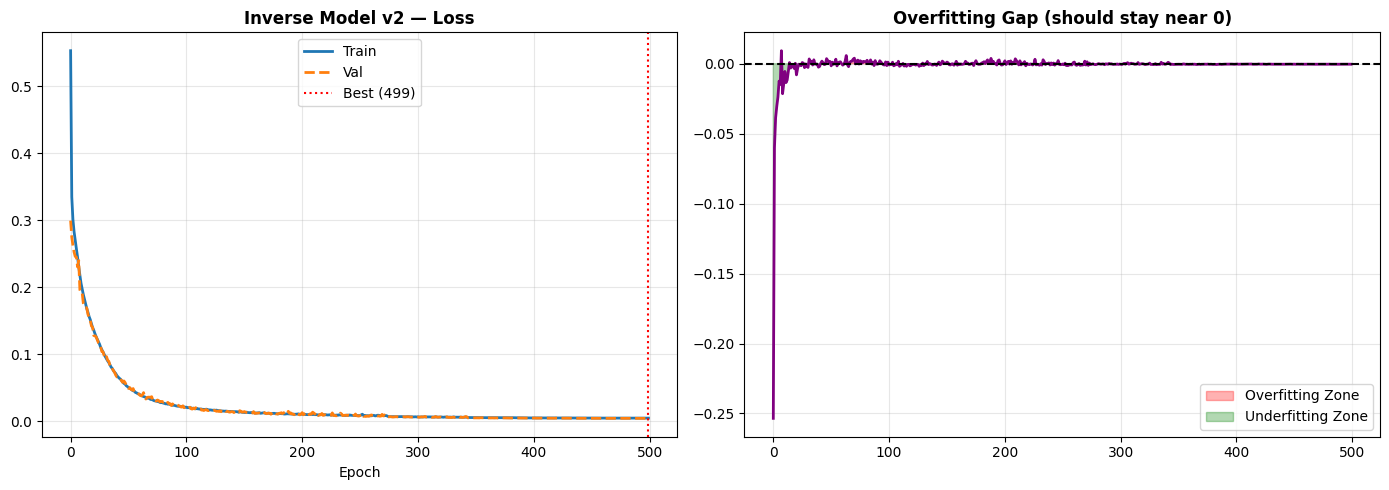

In [7]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_ep = np.argmin(hist_inv.history['val_loss'])

axes[0].plot(hist_inv.history['loss'],     label='Train', lw=2)
axes[0].plot(hist_inv.history['val_loss'], label='Val',   lw=2, ls='--')
axes[0].axvline(best_ep, color='red', ls=':', label=f'Best ({best_ep})')
axes[0].set_title('Inverse Model v2 — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

gap = np.array(hist_inv.history['val_loss']) - np.array(hist_inv.history['loss'])
axes[1].plot(gap, color='purple', lw=2)
axes[1].axhline(0, color='black', ls='--')
axes[1].fill_between(range(len(gap)), gap, 0,
                     where=(gap>0), alpha=0.3, color='red',   label='Overfitting Zone')
axes[1].fill_between(range(len(gap)), gap, 0,
                     where=(gap<0), alpha=0.3, color='green', label='Underfitting Zone')
axes[1].set_title('Overfitting Gap (should stay near 0)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inverse_training_v2.png', dpi=150, bbox_inches='tight')
plt.show()


  INVERSE MODEL v2 — TEST SET
  Dimension                   R²        MAE     MAPE%    OLD R²
----------------------------------------------------------------------
  Diameter                0.9952      0.199     1.53%  [old:0.635 +0.360]  ███████████████████
  Length                  0.9650      4.941     9.94%  [old:0.568 +0.397]  ███████████████████
  Core_Diameter           0.9926      0.076     3.07%  [old:0.792 +0.200]  ███████████████████
  Number_Of_Fins          0.9942      0.132     2.07%  [old:0.974 +0.020]  ███████████████████
  Fin_Length              0.9959      0.046     2.73%  [old:0.852 +0.144]  ███████████████████
  Fin_Width               0.9916      0.018     2.55%  [old:0.814 +0.178]  ███████████████████
  Throat_Diameter         0.9989      0.007     0.37%  [old:0.055 +0.944]  ███████████████████
  Exit_Diameter           0.9989      0.010     0.38%  [old:0.052 +0.947]  ███████████████████


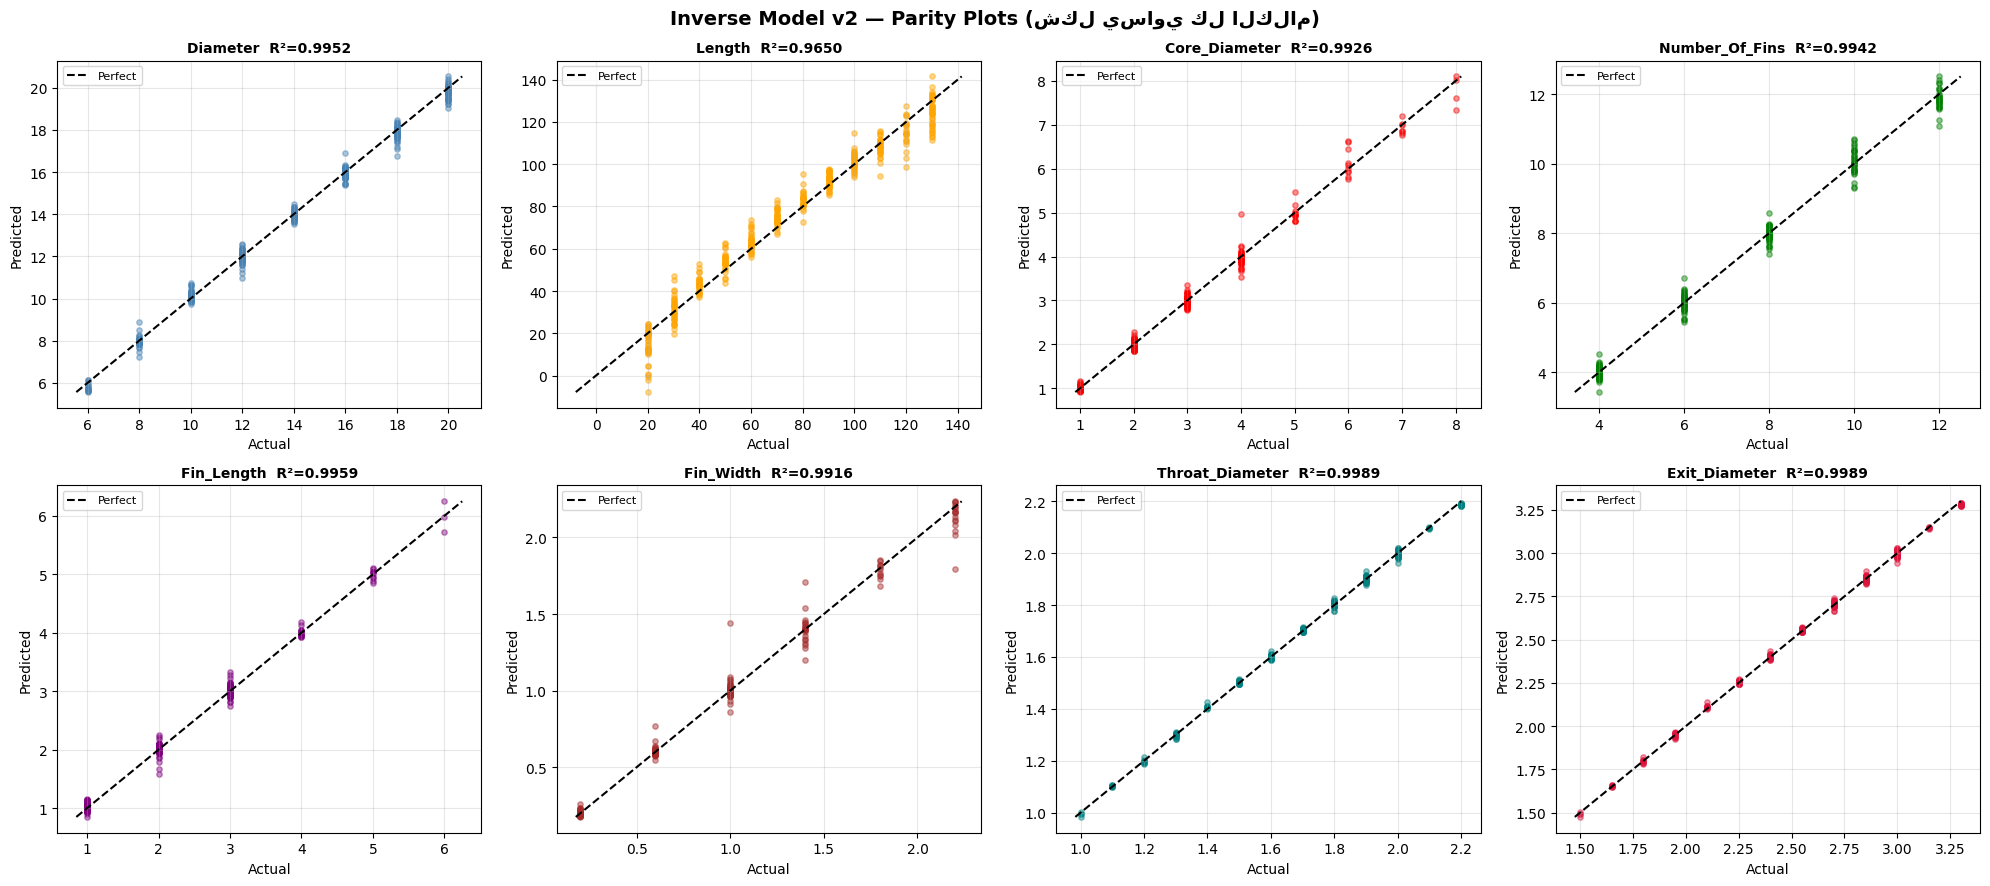

In [8]:
# ============================================================
# EVALUATION — TEST SET
# ============================================================

Yg_pred_s = inv_model_v2.predict([Xt_te, Xp_te, Xs_te_s], verbose=0)
Yg_pred   = inv_scaler_Y.inverse_transform(Yg_pred_s)
Yg_true   = inv_scaler_Y.inverse_transform(Yg_te_s)

print("=" * 70)
print("  INVERSE MODEL v2 — TEST SET")
print("=" * 70)
print(f"  {'Dimension':<22} {'R²':>7}  {'MAE':>9}  {'MAPE%':>8}  {'OLD R²':>8}")
print("-" * 70)

old_r2 = [0.6353, 0.5681, 0.7923, 0.9742, 0.8522, 0.8138, 0.0551, 0.0522]

for i, name in enumerate(INPUT_COLS):
    r2   = r2_score(Yg_true[:, i], Yg_pred[:, i])
    mae  = np.mean(np.abs(Yg_true[:, i] - Yg_pred[:, i]))
    mape = np.mean(np.abs((Yg_true[:, i] - Yg_pred[:, i]) /
                           (Yg_true[:, i] + 1e-8))) * 100
    bar  = '█' * int(max(r2, 0) * 20)
    delta = r2 - old_r2[i]
    delta_str = f'+{delta:.3f}' if delta > 0 else f'{delta:.3f}'
    print(f"  {name:<22} {r2:>7.4f}  {mae:>9.3f}  {mape:>7.2f}%  "
          f"[old:{old_r2[i]:.3f} {delta_str}]  {bar}")
print("=" * 70)

# Parity Plots
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
colors = ['steelblue','orange','red','green','purple','brown','teal','crimson']

for i, (name, color) in enumerate(zip(INPUT_COLS, colors)):
    ax = axes[i]
    mn = min(Yg_true[:, i].min(), Yg_pred[:, i].min())
    mx = max(Yg_true[:, i].max(), Yg_pred[:, i].max())
    ax.scatter(Yg_true[:, i], Yg_pred[:, i], alpha=0.45, s=15, color=color)
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect')
    r2 = r2_score(Yg_true[:, i], Yg_pred[:, i])
    ax.set_title(f'{name}  R²={r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle('Inverse Model v2 — Parity Plots (شكل يساوي كل الكلام)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inverse_parity_v2.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ============================================================
# تصحيح أسماء المتغيرات لـ show_uncertainty
# ============================================================

# Thrust و Pressure مش عندهم scaler خاص — بس الموديل بياخدهم كـ raw normalized curves
# لأن الـ augmentation عملت clip(0,1) عليهم وهما أصلاً normalized
Xt_te_s = Xt_te   # already normalized (0-1 range from interpolation)
Xp_te_s = Xp_te   # same

# Geometry
Y_te  = Yg_te     # الأبعاد الحقيقية (غير مقيسة)

# Scaler اسمه inv_scaler_Y مش s_Y
s_Y = inv_scaler_Y

print(f"✅ Test samples ready: {len(Y_te)}")

✅ Test samples ready: 384



🎯 MC Dropout Uncertainty — Sample #0
Dimension         Predicted       ±σ     Actual     Err% Confidence
Diameter             10.103    0.005     10.000     1.0%  🟢 High
Length               90.862    0.001     90.000     1.0%  🟢 High
Core_Diameter         1.867    0.051      2.000     6.7%  🟢 High
Number_Of_Fins        4.000    0.005      4.000     0.0%  🟢 High
Fin_Length            0.958    0.009      1.000     4.2%  🟢 High
Fin_Width             0.972    0.136      1.000     2.8%  🟡 Medium
Throat_Diameter       2.002    0.017      2.000     0.1%  🟢 High
Exit_Diameter         3.002    0.012      3.000     0.1%  🟢 High


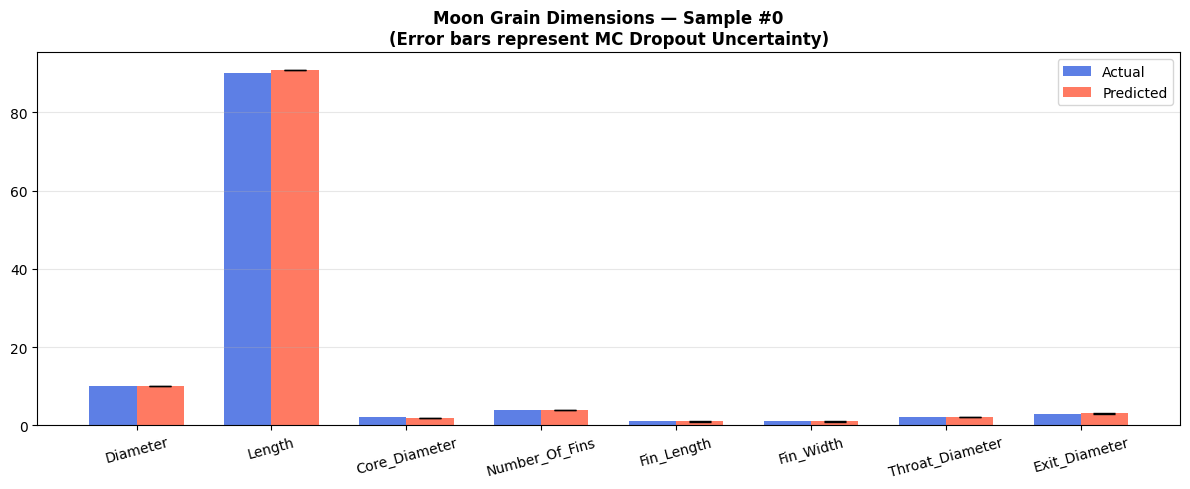


🎯 MC Dropout Uncertainty — Sample #35
Dimension         Predicted       ±σ     Actual     Err% Confidence
Diameter             19.514    0.006     20.000     2.4%  🟢 High
Length               21.541    0.001     20.000     7.7%  🟢 High
Core_Diameter         2.976    0.068      3.000     0.8%  🟢 High
Number_Of_Fins        3.931    0.010      4.000     1.7%  🟢 High
Fin_Length            1.039    0.015      1.000     3.9%  🟢 High
Fin_Width             1.801    0.255      1.800     0.1%  🟡 Medium
Throat_Diameter       1.306    0.039      1.300     0.4%  🟢 High
Exit_Diameter         1.959    0.026      1.950     0.4%  🟢 High


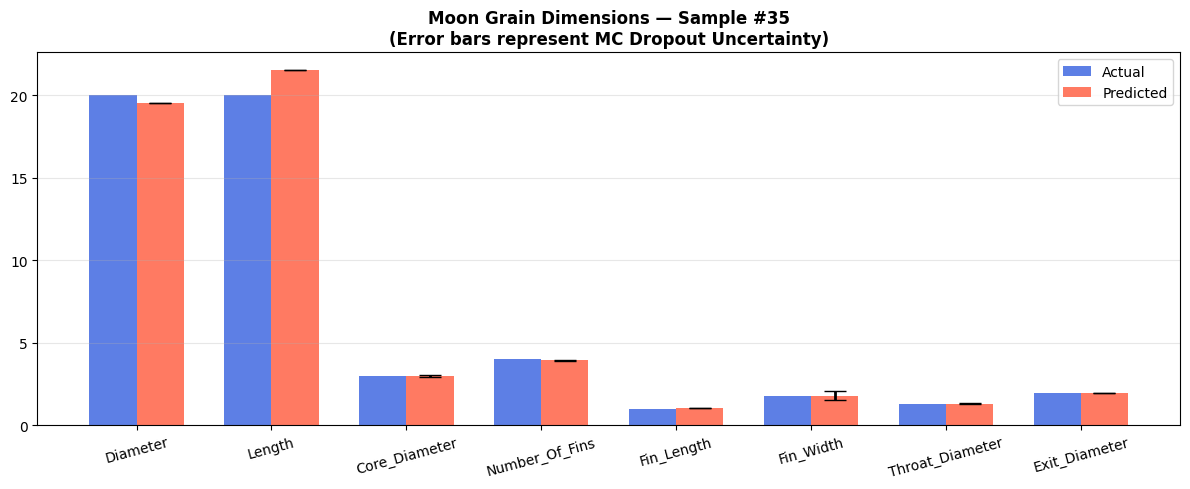


🎯 MC Dropout Uncertainty — Sample #99
Dimension         Predicted       ±σ     Actual     Err% Confidence
Diameter             10.647    0.007     10.000     6.5%  🟢 High
Length              133.137    0.001    130.000     2.4%  🟢 High
Core_Diameter         1.979    0.059      2.000     1.1%  🟢 High
Number_Of_Fins        6.173    0.009      6.000     2.9%  🟢 High
Fin_Length            3.087    0.024      3.000     2.9%  🟢 High
Fin_Width             0.603    0.061      0.600     0.4%  🟡 Medium
Throat_Diameter       2.095    0.059      2.100     0.3%  🟢 High
Exit_Diameter         3.142    0.039      3.150     0.3%  🟢 High


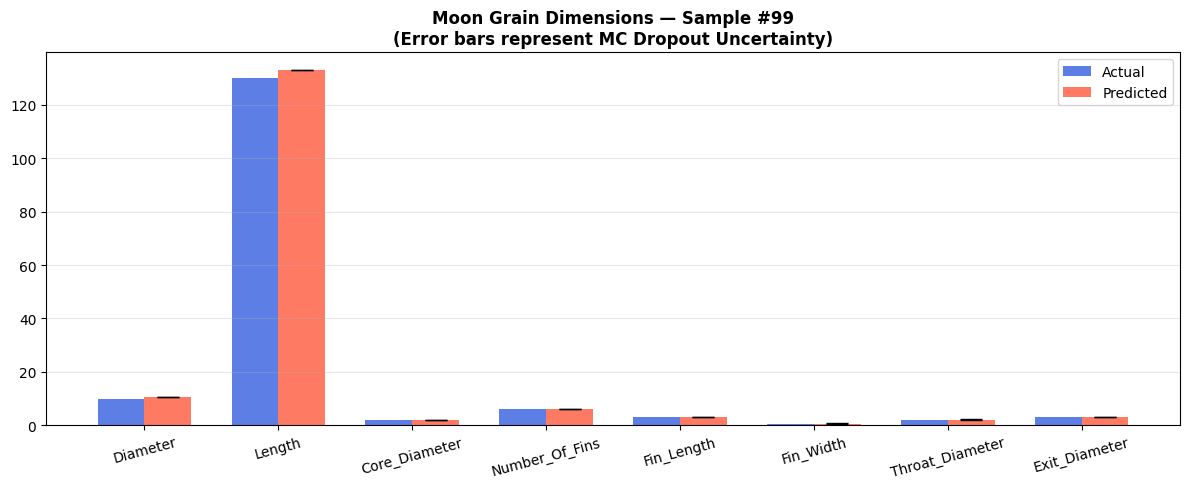

In [18]:
# ===================================================================
# 7. Monte Carlo Dropout for Uncertainty Estimation (Moon Grain)
# ===================================================================

@tf.function
def predict_with_dropout(inputs):
    # 'training=True' forces Dropout layers to remain active during prediction
    return inv_model_v2(inputs, training=True)

def mc_predict(t_in, p_in, s_in, n_iter=200):
    t_tensor = tf.constant(t_in, dtype=tf.float32)
    p_tensor = tf.constant(p_in, dtype=tf.float32)
    s_tensor = tf.constant(s_in, dtype=tf.float32)
    
    preds = []
    for _ in range(n_iter):
        # نقوم بتمرير training=True كـ argument مباشر لطبقات الـ Dropout
        out = inv_model_v2([t_tensor, p_tensor, s_tensor], training=True) 
        preds.append(out.numpy())
        
    preds_arr = np.stack(preds, axis=0)
    return preds_arr.mean(axis=0), preds_arr.std(axis=0)

def show_uncertainty(sample_idx=0):
    # 1. استخراج عينة اختبار واحدة (3 مدخلات للموديل العكسي)
    t_s = Xt_te_s[sample_idx:sample_idx+1]
    p_s = Xp_te_s[sample_idx:sample_idx+1]
    s_s = Xs_te_s[sample_idx:sample_idx+1]
    
    # الأبعاد الحقيقية للاختبار (غير مقيسة)
    actual = Y_te[sample_idx] 
    
    # 2. الحصول على تنبؤات Monte Carlo (مقيسة)
    pred_mean_s, pred_std_s = mc_predict(t_s, p_s, s_s, n_iter=200)
    
    # 3. عكس التقييس (Inverse Transform)
    # عكس المتوسط للحصول على الأبعاد المتوقعة
    pred_vals = s_Y.inverse_transform(pred_mean_s)[0]
    
    # عكس الانحراف المعياري
    # ملاحظة: مع MinMaxScaler نقوم بالقسمة على الـ scale_ للحصول على التشتت الحقيقي
    pred_unc = pred_std_s[0] / s_Y.scale_
    
    # تم إضافة الـ Core Offset ليصبحوا 6 أبعاد
    DIM_NAMES = ['Diameter', 'Length', 'Core_Diameter', 'Number_Of_Fins',
                'Fin_Length', 'Fin_Width', 'Throat_Diameter', 'Exit_Diameter']
    
    # 4. طباعة النتائج في جدول منسق
    print(f"\n🎯 MC Dropout Uncertainty — Sample #{sample_idx}")
    print("=" * 75)
    print(f"{'Dimension':<16} {'Predicted':>10} {'±σ':>8} {'Actual':>10} "
          f"{'Err%':>8} {'Confidence'}")
    print("=" * 75)
    
    for i, name in enumerate(DIM_NAMES):
        actual_val = actual[i]
        err = abs(pred_vals[i] - actual_val) / (actual_val + 1e-9) * 100
        
        # معامل الاختلاف (CV) لتقييم مستوى الثقة
        cv   = pred_unc[i] / (abs(pred_vals[i]) + 1e-9) * 100
        conf = "🟢 High" if cv < 5 else ("🟡 Medium" if cv < 15 else "🔴 Low")
        
        print(f"{name:<16} {pred_vals[i]:>10.3f} {pred_unc[i]:>8.3f} "
              f"{actual_val:>10.3f} {err:>7.1f}%  {conf}")
              
    print("=" * 75)

    # 5. رسم بياني شريطي (Bar chart visualization)
    # تم تكبير العرض قليلاً ليستوعب 6 أعمدة
    fig, ax = plt.subplots(figsize=(12, 5))
    x     = np.arange(8)
    width = 0.35
    
    # أعمدة القيم الحقيقية والمتوقعة
    ax.bar(x - width/2, actual,    width, label='Actual',    color='royalblue', alpha=0.85)
    ax.bar(x + width/2, pred_vals, width, label='Predicted', color='tomato',    alpha=0.85,
           yerr=pred_unc, capsize=8, error_kw={'linewidth': 2})
           
    ax.set_xticks(x)
    ax.set_xticklabels(DIM_NAMES, rotation=15, fontsize=10)
    ax.set_title(f'Moon Grain Dimensions — Sample #{sample_idx}\n'
                 f'(Error bars represent MC Dropout Uncertainty)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    # plt.savefig(f'moon_inverse_uncertainty_{sample_idx}.png', dpi=150)
    plt.show()

# ==========================================
# تشغيل الدالة على بعض العينات
show_uncertainty(0)
show_uncertainty(35)
show_uncertainty(99)


  Test Case 1
  Diameter               :   14.023  cm
  Length                 :   69.214  cm
  Core_Diameter          :    3.157  cm
  Number_Of_Fins         :    6.020  —
  Fin_Length             :    0.993  cm
  Fin_Width              :    0.200  cm
  Throat_Diameter        :    1.990  cm
  Exit_Diameter          :    2.985  cm
  Burn Time   : 5.185 s
  Max Thrust  : 12709.02 N
  Max Pressure: 30.90 MPa
  Total Impulse: 31577.8 Ns


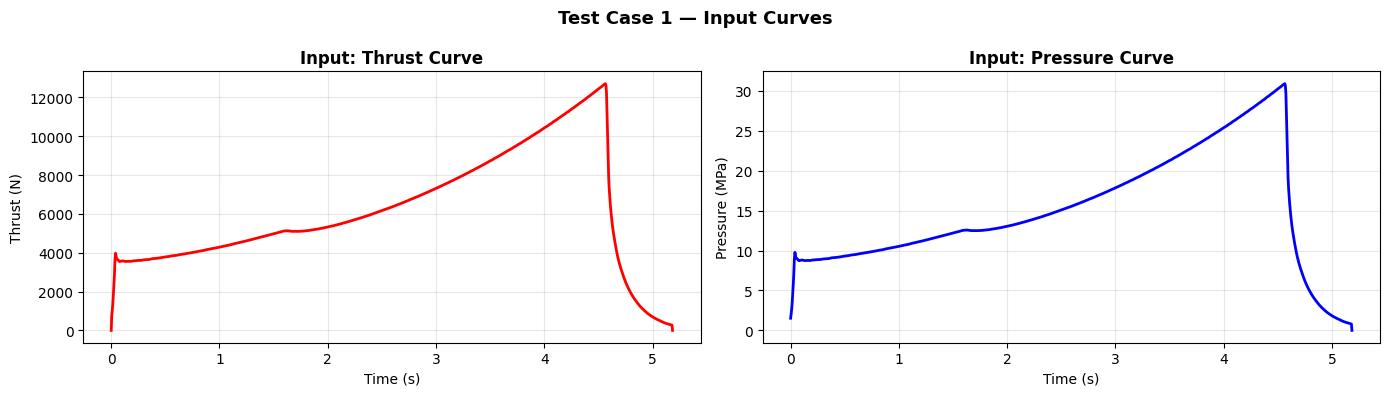

In [19]:
# ============================================================
# PREDICTION FUNCTION v2
# ============================================================

def predict_geometry_v2(file_path,
                        model=inv_model_v2,
                        scaler_Y=inv_scaler_Y,
                        scaler_S=inv_scaler_S,
                        num_points=INV_NUM_POINTS,
                        label='Predicted Geometry'):
    """
    يأخذ ملف Excel/CSV يحتوي على [Time (s), Pressure (MPa), Thrust (N)]
    ويُرجع الأبعاد الهندسية الـ 8 المتوقعة.
    
    الفرق عن الإصدار القديم: يستخدم أيضًا الـ scalar features
    (Max Thrust, Burn Time, إلخ) لتحسين الدقة بشكل جذري.
    """
    if file_path.endswith(('.xlsx', '.xls')):
        raw = pd.read_excel(file_path)
    else:
        raw = pd.read_csv(file_path, on_bad_lines='skip')
    raw.columns = raw.columns.str.strip()

    for col in ['Time (s)', 'Pressure (MPa)', 'Thrust (N)']:
        if col not in raw.columns:
            raise ValueError(f"Missing column: '{col}'")

    raw    = raw.dropna().sort_values('Time (s)')
    t      = raw['Time (s)'].values.astype(float)
    thrust = np.clip(raw['Thrust (N)'].values.astype(float), 0, None)
    press  = np.clip(raw['Pressure (MPa)'].values.astype(float), 0, None)

    # Scalar features (قبل normalization)
    scalars = extract_scalar_features(t, thrust, press)
    scalars_s = scaler_S.transform(scalars.reshape(1, -1))

    # Curve normalization
    t_norm = (t - t[0]) / (t[-1] - t[0])
    t_new  = np.linspace(0, 1, num_points)
    thr_r  = np.clip(interp1d(t_norm, thrust, kind='linear',
                               fill_value='extrapolate')(t_new), 0, None)
    prs_r  = np.clip(interp1d(t_norm, press,  kind='linear',
                               fill_value='extrapolate')(t_new), 0, None)

    thr_r /= (np.max(thr_r) + 1e-8)
    prs_r /= (np.max(prs_r) + 1e-8)
    thr_r  = np.clip(savgol_filter(thr_r, 15, 3), 0, None)
    prs_r  = np.clip(savgol_filter(prs_r, 15, 3), 0, None)

    pred_s = model.predict(
        [thr_r.reshape(1, num_points),
         prs_r.reshape(1, num_points),
         scalars_s], verbose=0)
    pred   = scaler_Y.inverse_transform(pred_s)[0]
    result = dict(zip(INPUT_COLS, pred))

    print("\n" + "="*52)
    print(f"  {label}")
    print("="*52)
    units = ['cm','cm','cm','—','cm','cm','cm','cm']
    for (k, v), u in zip(result.items(), units):
        print(f"  {k:<22} : {v:>8.3f}  {u}")
    print("="*52)
    print(f"  Burn Time   : {t[-1]:.3f} s")
    print(f"  Max Thrust  : {np.max(thrust):.2f} N")
    print(f"  Max Pressure: {np.max(press):.2f} MPa")
    print(f"  Total Impulse: {np.trapz(thrust, t):.1f} Ns")
    print("="*52)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(t, thrust, color='red',  lw=2)
    axes[0].set_title('Input: Thrust Curve', fontweight='bold')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t, press, color='blue', lw=2)
    axes[1].set_title('Input: Pressure Curve', fontweight='bold')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'{label} — Input Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{label.replace(" ","_")}_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    return result


# ← ضع مسار ملف الـ CSV/Excel هنا
result1 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-1847-test/1847.0.xlsx', label='Test Case 1')



  Test Case 2
  Diameter               :    6.239  cm
  Length                 :   25.591  cm
  Core_Diameter          :    2.019  cm
  Number_Of_Fins         :    5.924  —
  Fin_Length             :    1.069  cm
  Fin_Width              :    0.613  cm
  Throat_Diameter        :    1.011  cm
  Exit_Diameter          :    1.517  cm
  Burn Time   : 2.080 s
  Max Thrust  : 998.80 N
  Max Pressure: 10.12 MPa
  Total Impulse: 1264.0 Ns


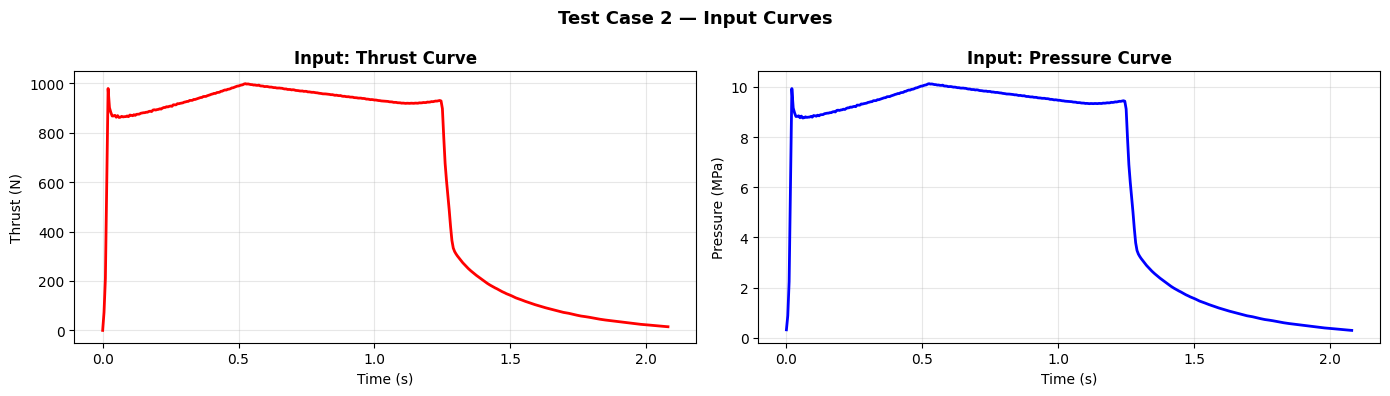

In [20]:
result1 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-2-test/2.0.xlsx', label='Test Case 2')


  Test Case 2
  Diameter               :    7.583  cm
  Length                 :  101.150  cm
  Core_Diameter          :    1.863  cm
  Number_Of_Fins         :   10.047  —
  Fin_Length             :    0.981  cm
  Fin_Width              :    0.185  cm
  Throat_Diameter        :    1.803  cm
  Exit_Diameter          :    2.705  cm
  Burn Time   : 1.695 s
  Max Thrust  : 13196.62 N
  Max Pressure: 39.62 MPa
  Total Impulse: 13886.5 Ns


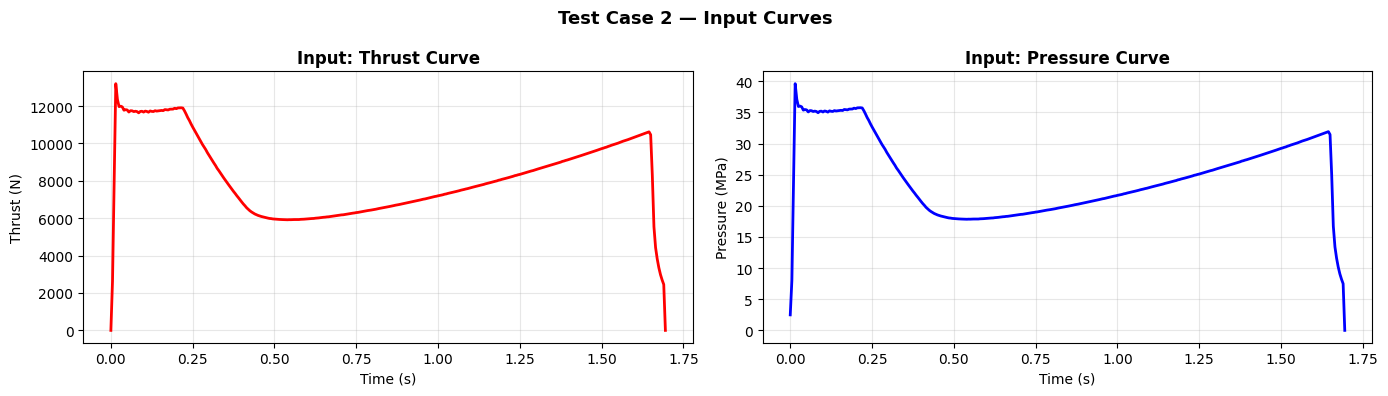

In [21]:
result2 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-2678-test/2678.0.xlsx', label='Test Case 2')


  Test Case 2
  Diameter               :   20.050  cm
  Length                 :  118.966  cm
  Core_Diameter          :    0.972  cm
  Number_Of_Fins         :    4.035  —
  Fin_Length             :    2.002  cm
  Fin_Width              :    0.594  cm
  Throat_Diameter        :    1.997  cm
  Exit_Diameter          :    2.996  cm
  Burn Time   : 5.115 s
  Max Thrust  : 55018.21 N
  Max Pressure: 133.27 MPa
  Total Impulse: 105925.3 Ns


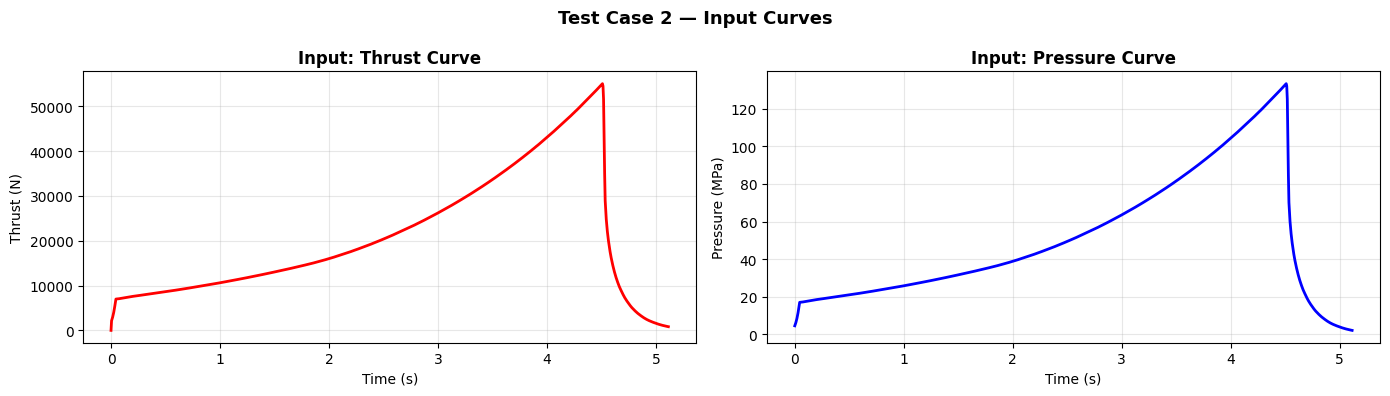

In [22]:
result3 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-3243-test/3243.0.xlsx', label='Test Case 2')


  Test Case 2
  Diameter               :   18.173  cm
  Length                 :  114.974  cm
  Core_Diameter          :    1.049  cm
  Number_Of_Fins         :    4.005  —
  Fin_Length             :    2.088  cm
  Fin_Width              :    0.599  cm
  Throat_Diameter        :    1.596  cm
  Exit_Diameter          :    2.394  cm
  Burn Time   : 3.100 s
  Max Thrust  : 76319.61 N
  Max Pressure: 289.41 MPa
  Total Impulse: 93104.3 Ns


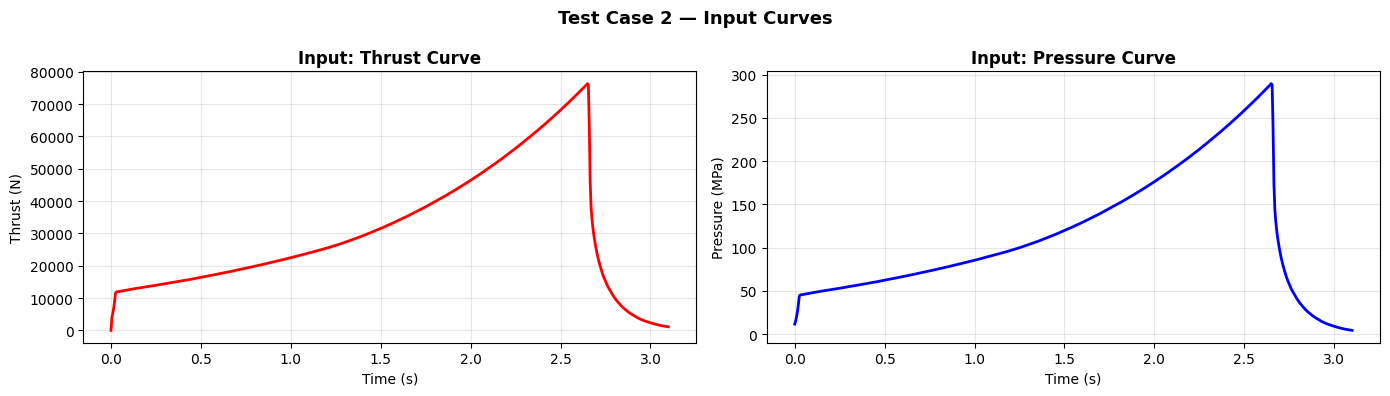

In [23]:
result4 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-3487-test/3487.0.xlsx', label='Test Case 2')



  Test Case 2
  Diameter               :   11.949  cm
  Length                 :   43.041  cm
  Core_Diameter          :    3.893  cm
  Number_Of_Fins         :   10.213  —
  Fin_Length             :    1.004  cm
  Fin_Width              :    0.194  cm
  Throat_Diameter        :    1.717  cm
  Exit_Diameter          :    2.576  cm
  Burn Time   : 3.775 s
  Max Thrust  : 4580.94 N
  Max Pressure: 15.52 MPa
  Total Impulse: 12107.2 Ns


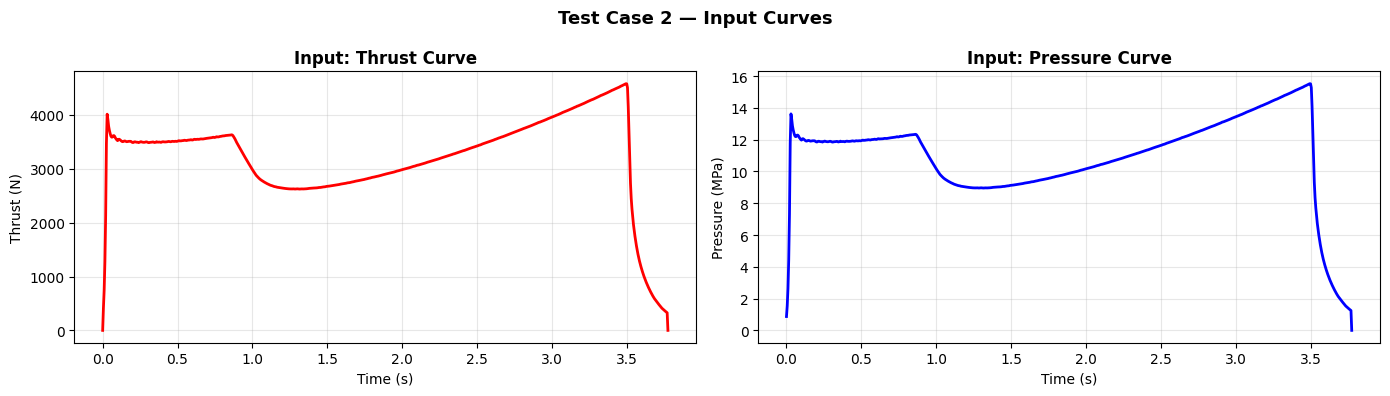

In [24]:
result5 = predict_geometry_v2('/kaggle/input/datasets/mohamedeidshehata6/finocyl-787-test/787.0.xlsx', label='Test Case 2')


In [27]:
df = pd.read_csv("/kaggle/input/datasets/mohamedeidshehata6/finocyl-new-data/Finocyl_new_data.csv")
df[df['ID'] == 3487].head()

,Time (s),Pressure (MPa),Thrust (N),ID,Length,Diameter,Core_Diameter,Number_Of_Fins,Fin_Length,Fin_Width,Throat_Diameter,Exit_Diameter,Total Impulse (Ns),ISP (s),Max Thrust (N),Peak Pressure (MPa),Burn Time (s),Avg Thrust (N)
3053065,0.000,11.6272,0.0000,3487,120,18,1,4,2,0.6,1.6,2.4,93107.055,174.714,76319.605,289.41,3.1,29986.169
3053066,0.005,15.3705,4015.3394,3487,120,18,1,4,2,0.6,1.6,2.4,93107.055,174.714,76319.605,289.41,3.1,29986.169
3053067,0.010,20.1746,5282.8687,3487,120,18,1,4,2,0.6,1.6,2.4,93107.055,174.714,76319.605,289.41,3.1,29986.169
3053068,0.015,26.3012,6899.3541,3487,120,18,1,4,2,0.6,1.6,2.4,93107.055,174.714,76319.605,289.41,3.1,29986.169
3053069,0.020,34.0731,8949.9399,3487,120,18,1,4,2,0.6,1.6,2.4,93107.055,174.714,76319.605,289.41,3.1,29986.169


In [13]:
df_models = df.groupby('ID')[['Diameter','Core_Diameter','Fin_Length']].first()
df_models['core_ratio'] = df_models['Core_Diameter'] / df_models['Diameter']

print(df_models['core_ratio'].describe())
print(df_models['Core_Diameter'].value_counts().sort_index())
print(df_models['Fin_Length'].value_counts().sort_index())

count    3900.000000
mean        0.185141
std         0.106167
min         0.050000
25%         0.111111
50%         0.166667
75%         0.250000
max         0.666667
Name: core_ratio, dtype: float64
Core_Diameter
1     827
2    1816
3     556
4     340
5     130
6     126
7      50
8      55
Name: count, dtype: int64
Fin_Length
1    2080
2     824
3     702
4     150
5     111
6      33
Name: count, dtype: int64


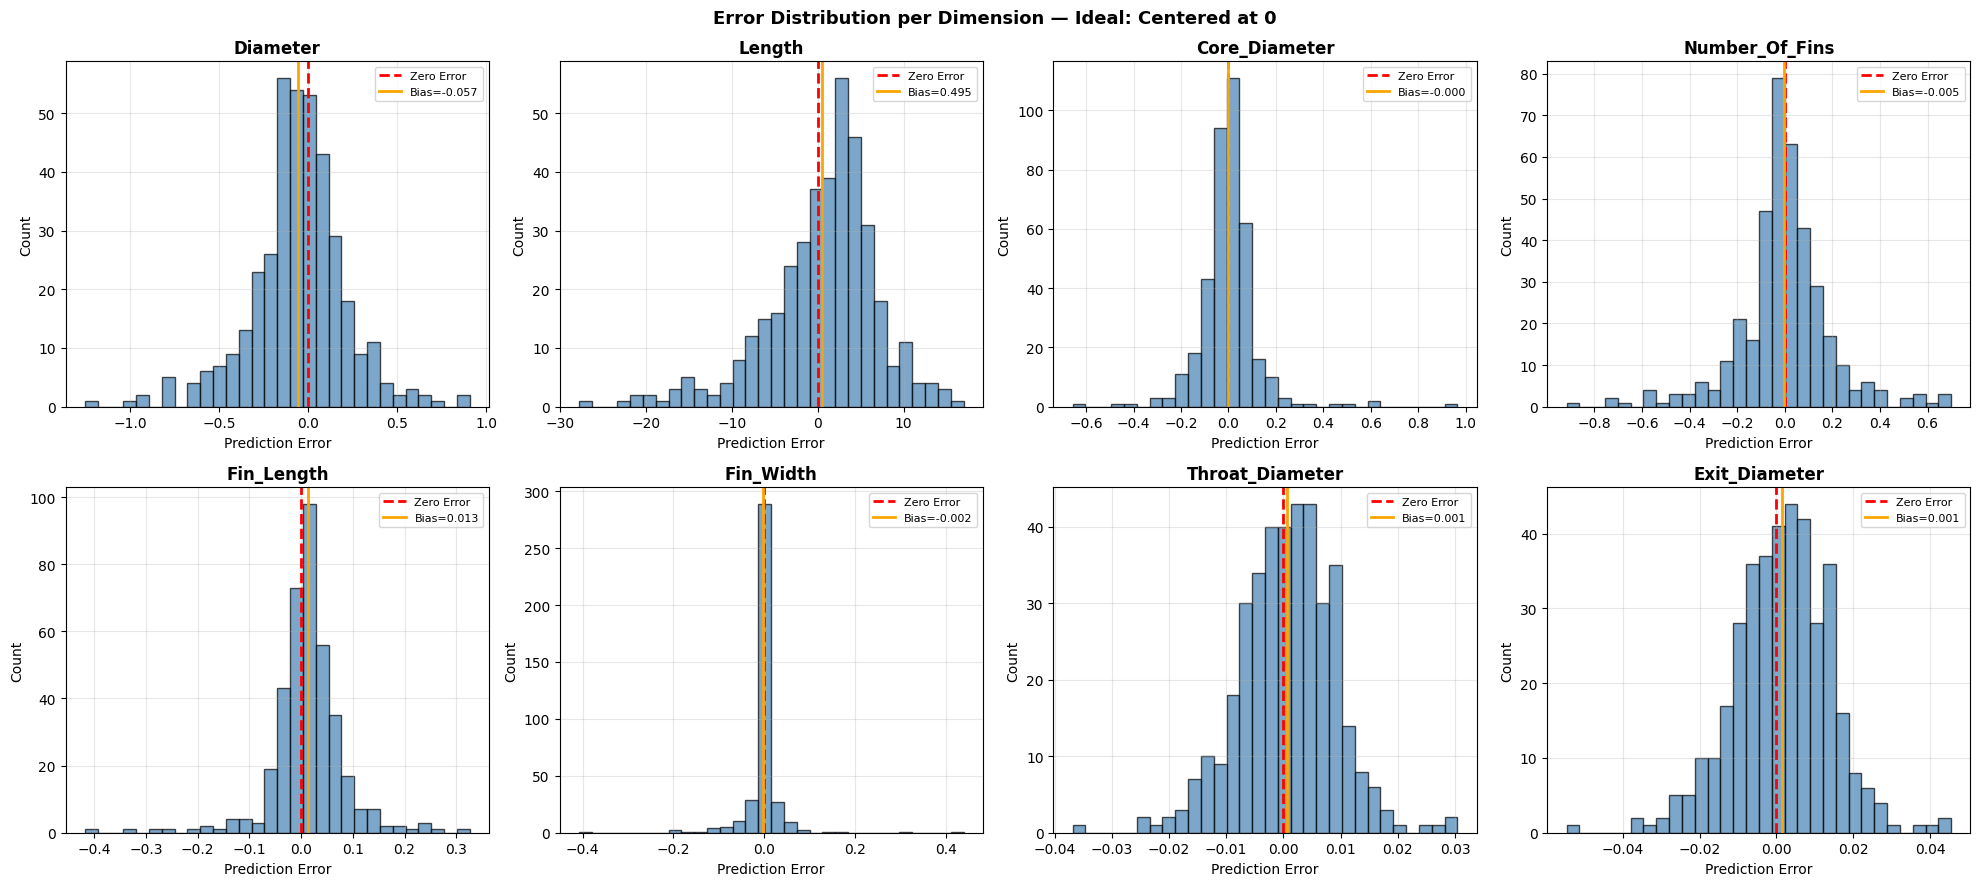


Bias analysis (ideally near 0):
  Diameter              : bias = -0.0569
  Length                : bias = +0.4949
  Core_Diameter         : bias = -0.0001
  Number_Of_Fins        : bias = -0.0053
  Fin_Length            : bias = +0.0133
  Fin_Width             : bias = -0.0023
  Throat_Diameter       : bias = +0.0006
  Exit_Diameter         : bias = +0.0014


In [14]:
# ============================================================
# ERROR ANALYSIS — لفهم ما يتعلمه الموديل
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

errors = Yg_pred - Yg_true

for i, name in enumerate(INPUT_COLS):
    ax = axes[i]
    ax.hist(errors[:, i], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', ls='--', lw=2, label='Zero Error')
    ax.axvline(errors[:, i].mean(), color='orange', ls='-', lw=2,
               label=f'Bias={errors[:, i].mean():.3f}')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Prediction Error'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Error Distribution per Dimension — Ideal: Centered at 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Print bias
print("\nBias analysis (ideally near 0):")
for i, name in enumerate(INPUT_COLS):
    bias = errors[:, i].mean()
    print(f"  {name:<22}: bias = {bias:+.4f}")
